# Detection & Classification with Device Selection

## Prerequesities 

OpenVINO needs to be installed prioir to runign this. Tested on version 2025.2.0.

In [7]:
%pip install -Uq openvino
%pip install -Uq ipywidgets jupyterlab_widgets

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [1]:
pip show openvino

Name: openvino
Version: 2025.3.0
Summary: OpenVINO(TM) Runtime
Home-page: https://docs.openvino.ai/2023.0/index.html
Author: 
Author-email: OpenVINO Developers <openvino@intel.com>
License: OSI Approved :: Apache Software License
Location: C:\Users\mkronbe\AppData\Local\Programs\Python\Python313\Lib\site-packages
Requires: numpy, openvino-telemetry, packaging
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install Pillow

   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ---------------------------------------  6.8/7.0 MB 41.4 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 39.0 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [6]:
%pip install -Uq ultralytics

Note: you may need to restart the kernel to use updated packages.


In [1]:
import ipywidgets as widgets
import openvino as ov
import torch
import torchvision
import numpy as np
from pathlib import Path
from PIL import Image
from ultralytics import YOLO

core = ov.Core()

## Get Model

In [2]:

#Create Models directory if does not exist
models_dir = Path("./models")
models_dir.mkdir(exist_ok=True)

#DET_MODEL_NAME = "yolov8n"
DET_MODEL_NAME = "yolo11n"

IMAGE_PATH = Path("grocery.jpeg")
det_model = YOLO(models_dir / f"{DET_MODEL_NAME}.pt")
label_map = det_model.model.names


## Run without OpenVINO


image 1/1 C:\Users\mkronbe\OneDrive - Intel Corporation\Documents\GitHub\openvino_notebooks\notebooks\yolo-detection-classification\grocery.jpeg: 640x640 1 banana, 1 apple, 1 orange, 1 pizza, 455.7ms
Speed: 15.2ms preprocess, 455.7ms inference, 5.6ms postprocess per image at shape (1, 3, 640, 640)


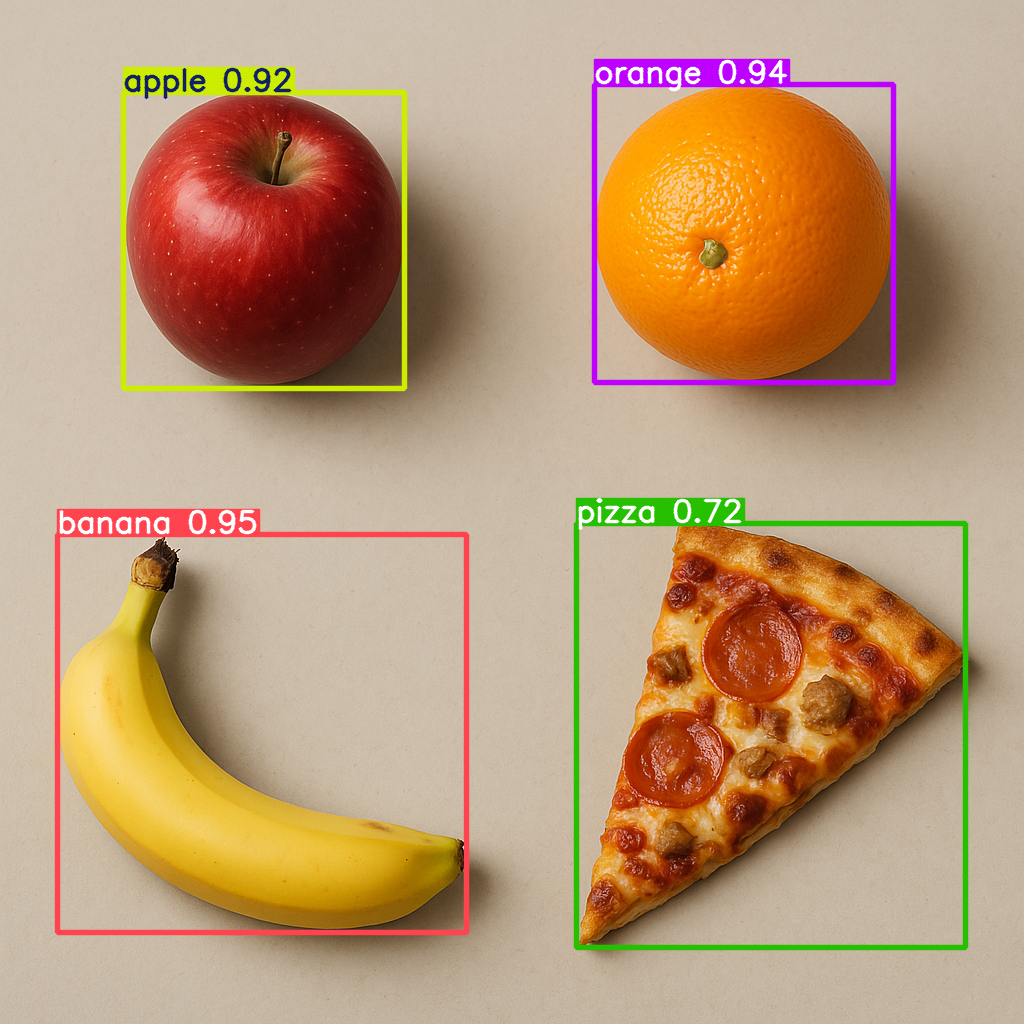

In [3]:

res = det_model(IMAGE_PATH)
Image.fromarray(res[0].plot()[:, :, ::-1])

### Convert Detect model to OpenVINO format

In [4]:
# Convert object detection model to OpenVINO format
det_model_path = models_dir / f"{DET_MODEL_NAME}_openvino_model/{DET_MODEL_NAME}.xml"
if not det_model_path.exists():
    det_model.export(format="openvino", dynamic=True, half=True)
    # Export the model

core = ov.Core()
det_ov_model = core.read_model(det_model_path)
print (det_ov_model)

<Model: 'Model0'
inputs[
<ConstOutput: names[x] shape[?,3,?,?] type: f32>
]
outputs[
<ConstOutput: names[] shape[?,84,21..] type: f32>
]>


## Select Device for Detection

Select device for Detection.  
Available options in your system are listed in the drop down box.  

In [5]:

detect_device = widgets.Dropdown(
    options=core.available_devices + ["AUTO"],
    value="CPU",
    description="Detection on",
    disabled=False,
)


display(detect_device)

Dropdown(description='Detection on', options=('CPU', 'GPU', 'AUTO'), value='CPU')

## Perform Object Detection Inference


image 1/1 C:\Users\mkronbe\OneDrive - Intel Corporation\Documents\GitHub\openvino_notebooks\notebooks\yolo-detection-classification\grocery.jpeg: 640x640 1 banana, 1 apple, 1 orange, 1 pizza, 305.2ms
Speed: 3.3ms preprocess, 305.2ms inference, 3.5ms postprocess per image at shape (1, 3, 640, 640)
  Inference Time: 305.18 ms


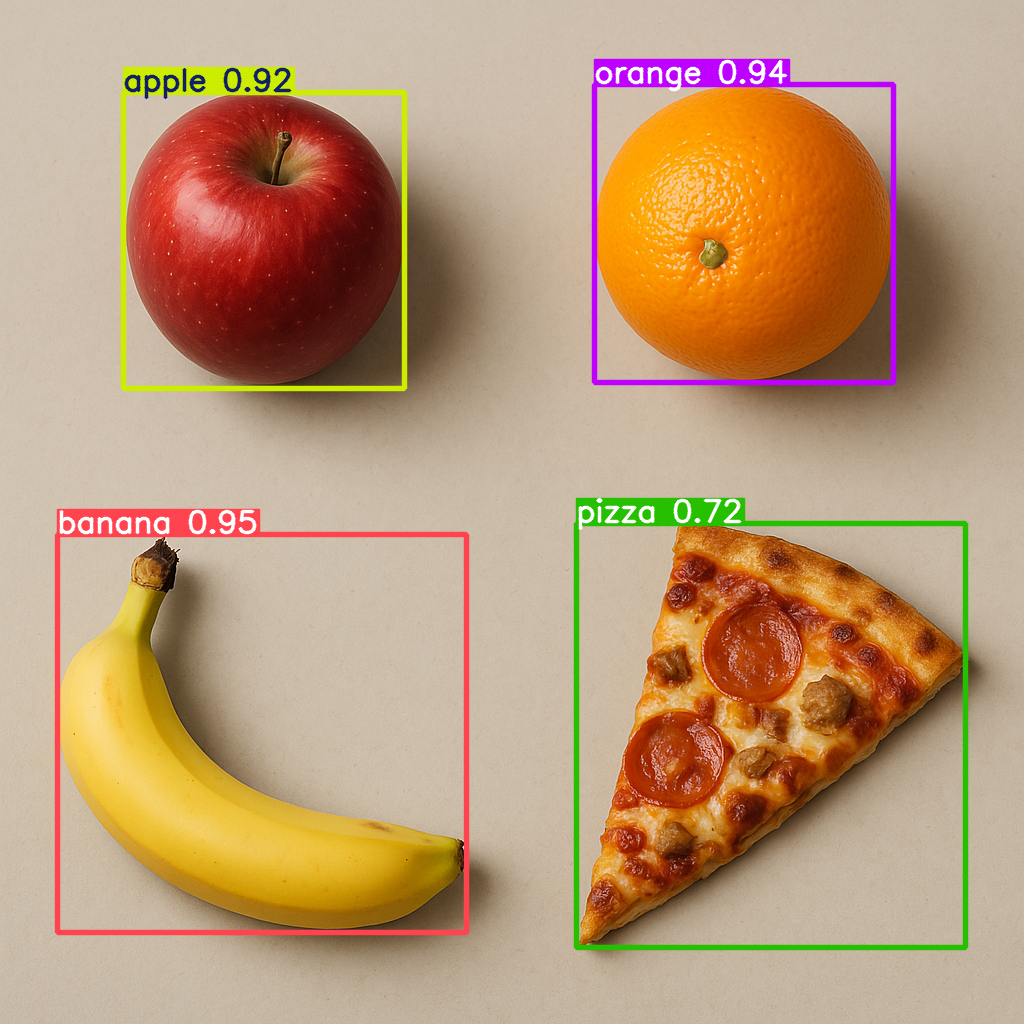

In [8]:
# Perform Obj Detect inference
detect_res = det_model(IMAGE_PATH)
# --- Print Inference Time ---
r = detect_res[0]
if hasattr(r, 'speed') and r.speed is not None:
    inference_time_ms = r.speed.get('inference', float('nan'))
    print(f"  Inference Time: {inference_time_ms:.2f} ms")
else:
    print("  Warning: Inference speed data not available in results.")

Image.fromarray(res[0].plot()[:, :, ::-1])

## Save cropped images

In [18]:
import cv2

# Load the image
image = cv2.imread(str(IMAGE_PATH))

# Extract cropped images
cropped_images = []
confidence_threshold = 0.5
for result in detect_res:
    boxes = result.boxes
    if len(boxes) > 0:  # Check if there are any detections
        for box in boxes:
            #print(box)
            confidence = box.conf.item()
            if confidence > confidence_threshold:
                x1, y1, x2, y2 = box.xyxy[0]  # Unpack the bounding box coordinates
                #print(x1,y1,x2,y2)
                cropped_image = image[int(y1):int(y2), int(x1):int(x2)]
                cropped_images.append(cropped_image)
                #cv2.imshow('Cropped Image', cropped_image)
                #cv2.waitKey(0)
                #cv2.destroyAllWindows()

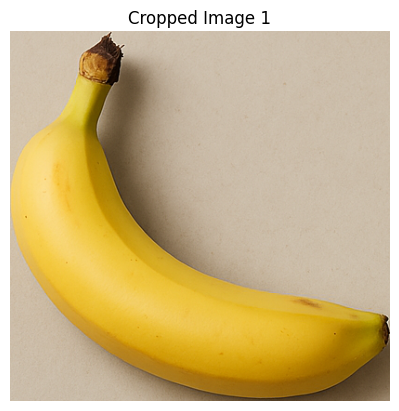

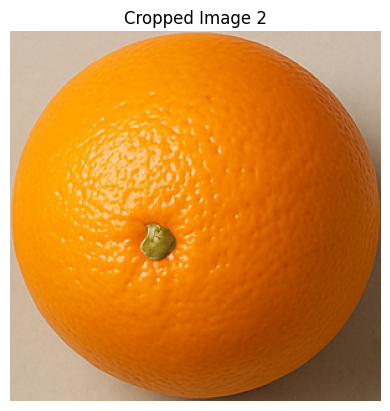

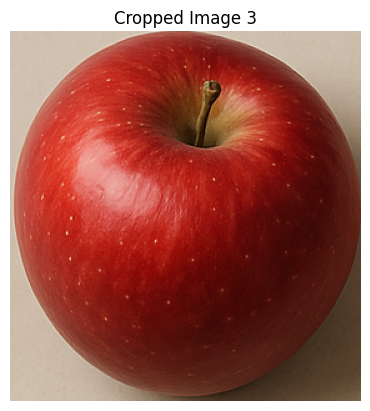

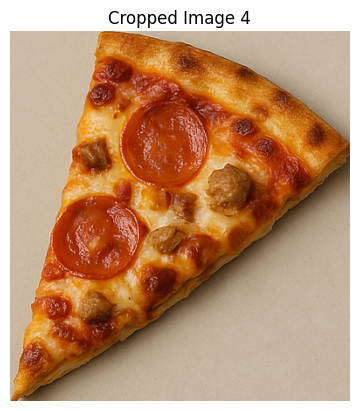

In [19]:
import matplotlib.pyplot as plt
for i,cropped_image in enumerate(cropped_images):
    image = Image.fromarray(cropped_image)
    # Convert the BGR image to RGB
    rgb_image = cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB)

    # Create a new figure for each image
    plt.figure()
    plt.imshow(rgb_image)
    plt.title(f"Cropped Image {i+1}")
    plt.axis('off') # Hide axes for cleaner image display
    plt.show() # Explicitly show the plot in the loop

## Classification

## DownLoad Classification Model

In [20]:
import os
CLASSIFICATION_MODEL_NAME = "yolo11n-cls"

class_model = YOLO(models_dir/f"{CLASSIFICATION_MODEL_NAME}.pt") 



## Select Device for Classification

In [9]:
classify_device = widgets.Dropdown(
    options=core.available_devices,
    value="CPU",
    description="Classify on",
    disabled=False,
)

display(classify_device)

Dropdown(description='Classify on', options=('CPU', 'GPU'), value='CPU')

In [22]:
#class_openvino_output_path = models_dir / f"{CLASSIFICATION_MODEL_NAME}_openvino_model/{CLASSIFICATION_MODEL_NAME}.xml"
class_openvino_output_path = models_dir / f"{CLASSIFICATION_MODEL_NAME}_openvino_model/"

print (class_openvino_output_path)

# Exporting this PyTorch model to OpenVINO IR
if not class_openvino_output_path.exists():
    class_model.export(format="openvino")
    print("generated openvino model")


models\yolo11n-cls_openvino_model
Ultralytics 8.3.200  Python-3.13.6 torch-2.8.0+cpu CPU (13th Gen Intel Core i7-1370P)
YOLO11n-cls summary (fused): 47 layers, 2,807,024 parameters, 0 gradients, 4.2 GFLOPs

PyTorch: starting from 'models\yolo11n-cls.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 1000) (5.5 MB)

OpenVINO: starting export with openvino 2025.3.0-19807-44526285f24-releases/2025/3...
OpenVINO: export success  4.6s, saved as 'models\yolo11n-cls_openvino_model\' (10.9 MB)

Export complete (4.9s)
Results saved to C:\Users\mkronbe\OneDrive - Intel Corporation\Documents\GitHub\openvino_notebooks\notebooks\yolo-detection-classification\models
Predict:         yolo predict task=classify model=models\yolo11n-cls_openvino_model imgsz=224  
Validate:        yolo val task=classify model=models\yolo11n-cls_openvino_model imgsz=224 data=../datasets/imagenet  
Visualize:       https://netron.app
generated openvino model


## Do Classification Inference

In [23]:
class_ov_model = YOLO(str(class_openvino_output_path))

In [24]:
if classify_device.value=="GPU":
    class_device_to_use = "intel:gpu"
else:
    class_device_to_use = "CPU"


In [25]:


if not cropped_images:
    print("The 'cropped_images' list is empty. No images to process.")
else:
    for i, img_data in enumerate(cropped_images):
        print(f"\nProcessing image {i+1}/{len(cropped_images)}") 

        try:
            # Perform Inference on the current image data
            print(f"Perforing Classification on device -{classify_device.value}")
            class_results = class_ov_model.predict(
                source=img_data,       # Pass the image data directly
                conf=0.5,             # Classification confidence threshold
                imgsz=224,             # Input image size (match your model's expected input)
                device= class_device_to_use,  #classify_device.value,          
                verbose=False          # Suppress verbose output for each image if desired
            )

            # Assuming 'results' is the list returned by ov_model.predict(source=img_data, ...)

            if class_results: # Check if the list is not empty
                # Get the first (and usually only) result object
                r = class_results[0]
    
                if hasattr(r, 'probs') and r.probs is not None:
                    top1_index = r.probs.top1         # Index of the top class
                    top1_confidence = r.probs.top1conf.item() # Confidence of the top class
                    class_names = r.names # Dictionary mapping class IDs to names
                    top_class_name = class_names[top1_index]
                    print(f"  Class: {top_class_name}, Probability: {top1_confidence:.4f}")
                else:
                    print("  No classification probabilities found for this image.")
                
                # Get Inference Time
                inference_time_ms = float('nan') # Initialize as Not-a-Number
                if hasattr(r, 'speed') and r.speed is not None:
                    inference_time_ms = r.speed.get('inference', float('nan'))
                    print(f"  Inference Time: {inference_time_ms}")
            else:
                print("No results returned for this image.")
            
        except Exception as e:
            print(f"  Error during inference for image {i+1}: {e}")




Processing image 1/4
Perforing Classification on device -CPU
Loading models\yolo11n-cls_openvino_model for OpenVINO inference...
Using OpenVINO LATENCY mode for batch=1 inference on (CPU)...
  Class: banana, Probability: 0.9997
  Inference Time: 6.756200000381796

Processing image 2/4
Perforing Classification on device -CPU
  Class: orange, Probability: 0.9927
  Inference Time: 6.844300000011572

Processing image 3/4
Perforing Classification on device -CPU
  Class: Granny_Smith, Probability: 0.5158
  Inference Time: 6.3902000001689885

Processing image 4/4
Perforing Classification on device -CPU
  Class: pizza, Probability: 0.8433
  Inference Time: 7.840000000214786


## Measure Detection & Classification Pipeline 

In [10]:

Pipeline_detect_device = widgets.Dropdown(
    options=core.available_devices,
    value="CPU",
    description="Detection on",
    disabled=False,
)
Pipeline_classify_device = widgets.Dropdown(
    options=core.available_devices,
    value="CPU",
    description="Classify on",
    disabled=False,
) 

display(Pipeline_detect_device, Pipeline_classify_device)

Dropdown(description='Detection on', options=('CPU', 'GPU'), value='CPU')

Dropdown(description='Classify on', options=('CPU', 'GPU'), value='CPU')

In [27]:
import time

#-------------------------------------
#Detection
#---------------------------------------
#Prepare Detection Model
ov_config = {}
print(Pipeline_detect_device.value)
if Pipeline_detect_device.value != "CPU":
    det_ov_model.reshape({0: [1, 3, 640, 640]})
    ov_config = {"GPU_DISABLE_WINOGRAD_CONVOLUTION": "YES"}
    #print("Detect:GPU")
det_compiled_model = core.compile_model(det_ov_model, Pipeline_detect_device.value, ov_config)
def infer(*args):
    result = det_compiled_model(args)
    return torch.from_numpy(result[0])

det_model.predictor.inference = infer
det_model.predictor.model.pt = False

#Preapre Classification model
class_ov_model = YOLO(str(class_openvino_output_path))
if Pipeline_classify_device.value=="GPU":
    pipeline_class_device_to_use = "intel:gpu"
    #if gpu used for classify, preload model to not have model loading time in measurement
    #dummy predict to load model on gpu
    dummy_img = Image.new('RGB', (224, 224), color = 'red') # Create a dummy 224x224 image
    dummy_img_np = np.array(dummy_img)
    class_results = class_ov_model.predict(
                source=dummy_img_np,       # Pass the image data directly
                conf=0.5,             # Classification confidence threshold
                imgsz=224,             # Input image size (match your model's expected input)
                device= pipeline_class_device_to_use,  #classify_device.value,          
                verbose=False          # Suppress verbose output for each image if desired
            ) 
else:
    pipeline_class_device_to_use = "CPU"



#-- Measurement : Start Timer
start_time = time.perf_counter()

#Detection inference
# Perform Obj Detect inference
detect_res = det_model(IMAGE_PATH)
# --- Print Inference Time ---
#r = detect_res[0]
# --- Print Inference Time ---
#r = detect_res[0]
#if hasattr(r, 'speed') and r.speed is not None:
#    inference_time_ms = r.speed.get('inference', float('nan'))
#    print(f"  Inference Time: {inference_time_ms:.2f} ms")
#else:
#    print("  Warning: Inference speed data not available in results.")


#-----------------------------------
# Save Crops
#-----------------------------------
# Load the image
image = cv2.imread(str(IMAGE_PATH))
# Extract cropped images
cropped_images = []
confidence_threshold = 0.5
for result in detect_res:
    boxes = result.boxes
    if len(boxes) > 0:  # Check if there are any detections
        for box in boxes:
            #print(box)
            confidence = box.conf.item()
            if confidence > confidence_threshold:
                x1, y1, x2, y2 = box.xyxy[0]  # Unpack the bounding box coordinates
                #print(x1,y1,x2,y2)
                cropped_image = image[int(y1):int(y2), int(x1):int(x2)]
                cropped_images.append(cropped_image)


#-----------------------------------
# Classification
#-----------------------------------
#class_ov_model = YOLO(str(class_openvino_output_path))



#Run Classificatio Inference
if not cropped_images:
    print("The 'cropped_images' list is empty. No images to process.")
else:
    start_time = time.perf_counter()
    for i, img_data in enumerate(cropped_images):
        try:
            # Perform Inference on the current image data
                      
            class_results = class_ov_model.predict(
                source=img_data,       # Pass the image data directly
                conf=0.5,             # Classification confidence threshold
                imgsz=224,             # Input image size (match your model's expected input)
                device= pipeline_class_device_to_use,  #classify_device.value,          
                verbose=False          # Suppress verbose output for each image if desired
            )      
        except Exception as e:
            print(f"  Error during inference for image {i+1}: {e}")


#-- End Timer
end_time = time.perf_counter()
#Calculate Time
elapsed_time = end_time - start_time

#Print Results
print("Number of items detected:",len(cropped_images))

#Total Pipeline Time
print("Total Pipeline time for Detect on",Pipeline_detect_device.value, "+ ",len(cropped_images),"items Classify on "+Pipeline_classify_device.value+" with Batch Size 1:", elapsed_time, "seconds")
 


CPU

image 1/1 C:\Users\mkronbe\OneDrive - Intel Corporation\Documents\GitHub\openvino_notebooks\notebooks\yolo-detection-classification\grocery.jpeg: 640x640 1 banana, 1 apple, 1 orange, 1 pizza, 110.8ms
Speed: 14.4ms preprocess, 110.8ms inference, 4.4ms postprocess per image at shape (1, 3, 640, 640)
Loading models\yolo11n-cls_openvino_model for OpenVINO inference...
Using OpenVINO LATENCY mode for batch=1 inference on (CPU)...
Number of items detected: 4
Total Pipeline time for Detect on CPU +  4 items Classify on CPU with Batch Size 1: 10.079988299999968 seconds


In [28]:
from IPython.display import display, HTML

# Example 2: Different color and size, plus bold
text1 = "Total Pipeline time for"
html_output1 = f"<p style='font-size: 24px; color: blue; font-weight: bold;'>{text1}</p>"
display(HTML(html_output1))

text2 = "Detect on - "+ Pipeline_detect_device.value
html_output2 = f"<p style='font-size: 20px; color: orange;font-weight: bold;'>{text2}</p>"
display(HTML(html_output2))

text3 = str(len(cropped_images))+" objects to Classify"
html_output3 = f"<p style='font-size: 20px; color: purple; font-weight: bold;'>{text3}</p>"
display(HTML(html_output3))

text4 = "Classify on - "+ Pipeline_classify_device.value
html_output4 = f"<p style='font-size: 20px; color: orange; font-weight: bold;'>{text4}</p>"
display(HTML(html_output4))

text5 = "with Batch Size 1 is : "
html_output5 = f"<p style='font-size: 20px; color: blue; font-weight: bold;'>{text5}</p>"
display(HTML(html_output5))

text5 = str( f"{elapsed_time*1000:.4f}")+ "milli seconds"
html_output5 = f"<p style='font-size: 24px; color: green; font-weight: bold;'>{text5}</p>"
display(HTML(html_output5))

